In [1]:
import gc
import torch

torch.cuda.empty_cache()
gc.collect()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-2-7b-hf')
model = AutoModelForCausalLM.from_pretrained('meta-llama/Llama-2-7b-hf', device_map="auto")
model.hf_device_map

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

{'model.embed_tokens': 0,
 'model.layers.0': 0,
 'model.layers.1': 0,
 'model.layers.2': 0,
 'model.layers.3': 0,
 'model.layers.4': 0,
 'model.layers.5': 0,
 'model.layers.6': 0,
 'model.layers.7': 0,
 'model.layers.8': 0,
 'model.layers.9': 0,
 'model.layers.10': 0,
 'model.layers.11': 0,
 'model.layers.12': 0,
 'model.layers.13': 0,
 'model.layers.14': 0,
 'model.layers.15': 0,
 'model.layers.16': 1,
 'model.layers.17': 1,
 'model.layers.18': 1,
 'model.layers.19': 1,
 'model.layers.20': 1,
 'model.layers.21': 1,
 'model.layers.22': 1,
 'model.layers.23': 1,
 'model.layers.24': 1,
 'model.layers.25': 1,
 'model.layers.26': 1,
 'model.layers.27': 1,
 'model.layers.28': 1,
 'model.layers.29': 1,
 'model.layers.30': 1,
 'model.layers.31': 1,
 'model.norm': 1,
 'model.rotary_emb': 1,
 'lm_head': 1}

In [3]:
q_proj_weight_7 = model.model.layers[7].self_attn.q_proj.weight
q_proj_weight_15 = model.model.layers[15].self_attn.q_proj.weight
q_proj_weight_23 = model.model.layers[23].self_attn.q_proj.weight

k_proj_weight_7 = model.model.layers[7].self_attn.k_proj.weight
k_proj_weight_15 = model.model.layers[15].self_attn.k_proj.weight
k_proj_weight_23 = model.model.layers[23].self_attn.k_proj.weight

mlp_gate_weight_7 = model.model.layers[7].mlp.gate_proj.weight
mlp_gate_weight_15 = model.model.layers[15].mlp.gate_proj.weight
mlp_gate_weight_23 = model.model.layers[23].mlp.gate_proj.weight

mlp_down_weight_7 = model.model.layers[7].mlp.down_proj.weight
mlp_down_weight_15 = model.model.layers[15].mlp.down_proj.weight
mlp_down_weight_23 = model.model.layers[23].mlp.down_proj.weight

In [4]:
from test_dbsf import *

In [ ]:
diagram0a = test_double_sparse(matrix=k_proj_weight_7, mask_type='blocks', total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

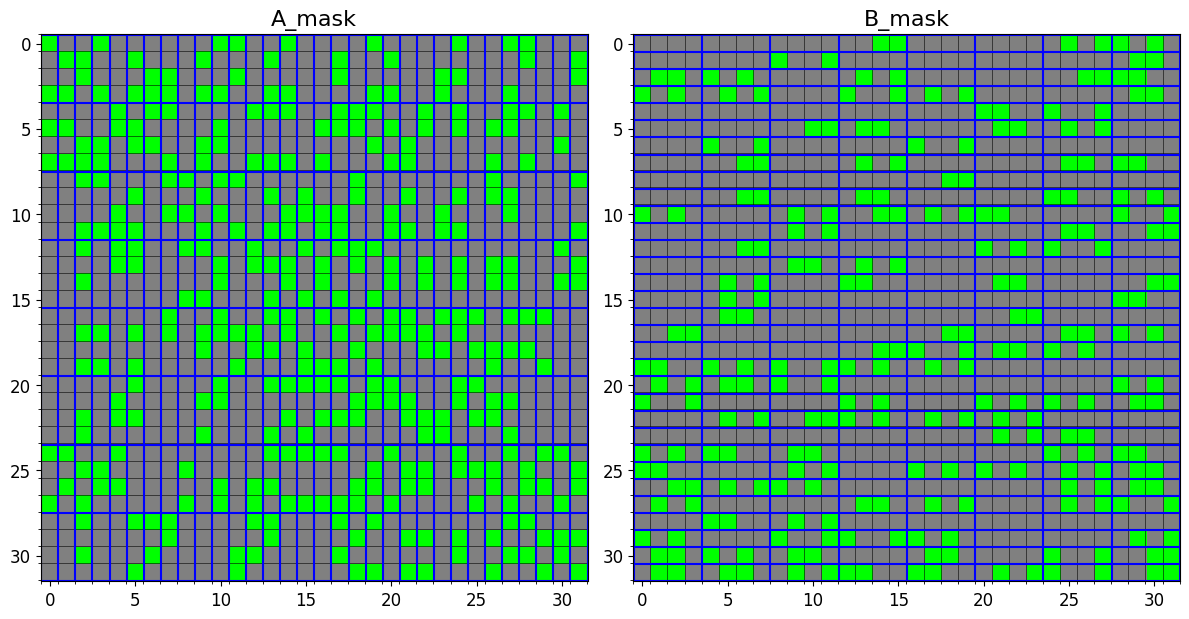

Frobenius norm: 13.99169635772705
A: tensor([[ 1.2628, -0.0000, -0.0000,  0.1883],
        [-0.0000,  0.8377, -0.1411,  0.0000],
        [ 0.0000,  0.0000,  1.3085, -0.0000],
        [ 0.3580, -0.2009,  0.0000,  1.4599]])
B: tensor([[ 0.0000, -0.0000, -0.0000, -0.0000],
        [ 0.0000,  0.0000, -0.0000, -0.0000],
        [ 0.0000,  0.0031, -0.0020, -0.0000],
        [-0.0011, -0.0000,  0.0027,  0.0000]])
A.size() = torch.Size([4096, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[-0.0004, -0.0028,  0.0028,  ..., -0.0013, -0.0144,  0.0031],
        [-0.0014,  0.0033, -0.0024,  ...,  0.0137, -0.0115, -0.0154],
        [ 0.0001,  0.0094, -0.0218,  ..., -0.0166,  0.0021,  0.0079],
        ...,
        [ 0.0009, -0.0323, -0.0327,  ..., -0.0168,  0.0313,  0.0374],
        [ 0.0131,  0.0596, -0.0405,  ..., -0.0159, -0.0665, -0.0560],
        [ 0.0796, -0.0265, -0.0156,  ...,  0.0803,  0.0343, -0.0102]])
Input matrix was: tensor([[ 6.8970e-03,  2.3804e-03,  3.3569e-03,  ...,  4.0283e

In [6]:
diagram0b = test_double_sparse(matrix=q_proj_weight_7, mask_type='2to4', total_sp=0.5, b_bias=0.5, mid_dim_scale=1)